# Module 02 — Pandas Essentials

*Real Antarctic fieldwork, in a table.*

Between 2007 and 2009, biologists at Palmer Station, Antarctica measured 344 penguins of three species — Adélie, Chinstrap, and Gentoo — across three islands. Unlike Module 01's tidy flowers, this is **real field data**: mixed types, and missing values where a penguin didn't cooperate.

**Pandas** gives us the `DataFrame`: a labeled table where every column can have its own type. Underneath, each column is a NumPy array — everything from Module 01 still applies.

Run each cell in order; predict before you run. As before, every non-obvious line has a `#` comment explaining it.

In [1]:
import numpy as np                # arrays (Module 01)
import pandas as pd               # tables -- the star of this module
import matplotlib.pyplot as plt   # drawing plots
import seaborn as sns             # nicer-looking plots

sns.set_theme(style="whitegrid", palette="colorblind")

# Same idea as Module 01: one fixed color per species, reused in every plot.
palette = sns.color_palette("colorblind")
SPECIES_COLORS = {"Adelie": palette[0], "Chinstrap": palette[1], "Gentoo": palette[2]}

## 1. Load the data

In [2]:
from datasets import load_dataset   # the HuggingFace downloader (same as Module 01)

# Download the penguins dataset, then convert it to a pandas DataFrame (a table).
penguins = load_dataset("SIH/palmer-penguins", split="train")
raw = penguins.to_pandas()   # named 'raw' because we haven't cleaned it yet

# Show the first 5 rows. 'NaN' (Not a Number) is how pandas displays MISSING values.
raw.head()

/Users/hari/repos/learning/scikit/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


## 2. The first-look ritual

Run these four on **every** dataset you ever open, before doing anything else:

1. `head()` — what do the rows actually look like?
2. `shape` — how much data is there?
3. `info()` — column types, and how many non-missing values each has
4. `describe()` — summary statistics for the numeric columns

In [3]:
print("shape:", raw.shape)   # (number of rows, number of columns)

# info() lists every column: how many non-missing values it has, and its type.
# 'float64' = decimal numbers; 'object' is pandas-speak for text.
raw.info()

shape: (344, 8)
<class 'pandas.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    str    
 1   island             344 non-null    str    
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    str    
 7   year               344 non-null    int64  
dtypes: float64(4), int64(1), str(3)
memory usage: 27.6 KB


In [4]:
# describe() summarizes each numeric column: count of non-missing values, mean,
# std (spread), min/max, and the 25%/50%/75% points ('50%' is the median).
raw.describe().round(1)   # .round(1) = show 1 decimal place

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,year
count,342.0,342.0,342.0,342.0,344.0
mean,43.9,17.2,200.9,4201.8,2008.0
std,5.5,2.0,14.1,802.0,0.8
min,32.1,13.1,172.0,2700.0,2007.0
25%,39.2,15.6,190.0,3550.0,2007.0
50%,44.4,17.3,197.0,4050.0,2008.0
75%,48.5,18.7,213.0,4750.0,2009.0
max,59.6,21.5,231.0,6300.0,2009.0


Read `describe()` like a biologist: body mass runs 2,700–6,300 g (a 2.3× range within "penguin"!), and the count row shows some columns have fewer than 344 values — missing data.

## 3. Missing values

`isna()` marks every missing cell `True`; summing counts them per column (True counts as 1, exactly like the masks in Module 01).

In [5]:
raw.isna().sum()   # missing-value count for each column

species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
year                  0
dtype: int64

In [6]:
# Before deleting anything, LOOK at the incomplete rows.
# Read inside-out: the inner part makes a True/False mask ('is bill length
# missing?'), and raw[mask] keeps only the rows where it's True.
raw[raw["bill_length_mm"].isna()]

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
271,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN,2009


Two penguins have **no measurements at all** (only species/island), and a handful more lack `sex`.

What to do about missing data is a *scientific* decision, not a technical one:

- **Drop the row** (`dropna()`) — right when the row is unusable or the loss is tiny
- **Fill it** (`fillna(...)`) — e.g. with a group average; right when you must keep every row, but it invents data
- **Keep the gaps** — many analyses tolerate them

Our analyses below use measurements *and* sex, and we'd lose only 11 of 344 rows — so we drop and keep going.

In [7]:
df = raw.dropna()   # a NEW table with every incomplete row removed ('raw' is untouched)

# len(...) counts rows; the f-string drops the two counts into the sentence.
print(f"kept {len(df)} of {len(raw)} penguins")

kept 333 of 344 penguins


## 4. Selecting columns and rows

- Square brackets with **one name** → a single column (pandas calls this a `Series`)
- Square brackets with a **list of names** (note the double `[[ ]]`) → a smaller table
- `df.iloc[...]` → rows by *position number*, like NumPy ("iloc" = integer location)

In [8]:
df["body_mass_g"].head()   # one column; .head() again shows the first 5 entries

0    3750.0
1    3800.0
2    3250.0
4    3450.0
5    3650.0
Name: body_mass_g, dtype: float64

In [9]:
# A list of column names inside the brackets -> that's why there are two [[ ]].
df[["species", "island", "body_mass_g"]].head()

,species,island,body_mass_g
0,Adelie,Torgersen,3750.0
1,Adelie,Torgersen,3800.0
2,Adelie,Torgersen,3250.0
4,Adelie,Torgersen,3450.0
5,Adelie,Torgersen,3650.0


In [10]:
df.iloc[0]   # the first row, displayed sideways with its column names

species                 Adelie
island               Torgersen
bill_length_mm            39.1
bill_depth_mm             18.7
flipper_length_mm        181.0
body_mass_g             3750.0
sex                       male
year                      2007
Name: 0, dtype: object

In [11]:
# Slices work like lists: 0:3 means rows 0,1,2 (the stop value is not included).
df.iloc[0:3, 0:4]   # first three rows, first four columns

,species,island,bill_length_mm,bill_depth_mm
0,Adelie,Torgersen,39.1,18.7
1,Adelie,Torgersen,39.5,17.4
2,Adelie,Torgersen,40.3,18.0


## 5. Filtering — boolean masks with names

Exactly the masking idiom from Module 01, but conditions now read like sentences. Combine conditions with `&` (and) or `|` (or) — each condition needs its own parentheses.

In [12]:
# All rows where the species column says 'Gentoo'.
gentoo = df[df["species"] == "Gentoo"]
print("Gentoo penguins:", len(gentoo))

# Three conditions combined with '&' -- a penguin must satisfy ALL of them.
big_gentoo_females = df[(df["species"] == "Gentoo")
                        & (df["sex"] == "female")
                        & (df["body_mass_g"] > 5000)]

# Show just the interesting columns of the result.
big_gentoo_females[["species", "island", "sex", "body_mass_g"]].head()

Gentoo penguins: 119


,species,island,sex,body_mass_g
184,Gentoo,Biscoe,female,5050.0
186,Gentoo,Biscoe,female,5150.0
200,Gentoo,Biscoe,female,5100.0
225,Gentoo,Biscoe,female,5200.0
274,Gentoo,Biscoe,female,5200.0


## 6. Counting categories

`value_counts()` answers "how many of each?"; `pd.crosstab` answers "how many of each **combination**?" — instant ecology: which species lives where?

In [13]:
df["species"].value_counts()   # how many penguins of each species

species
Adelie       146
Gentoo       119
Chinstrap     68
Name: count, dtype: int64

In [14]:
# Rows = species, columns = islands, cells = how many penguins of that combination.
pd.crosstab(df["species"], df["island"])

island,Biscoe,Dream,Torgersen
species,,,
Adelie,44,55,47
Chinstrap,0,68,0
Gentoo,119,0,0


Adélie penguins breed on all three islands; Chinstrap only on Dream; Gentoo only on Biscoe. An island-by-island field guide from one line of code.

Let's plot those counts — a grouped bar chart, one fixed color per species:

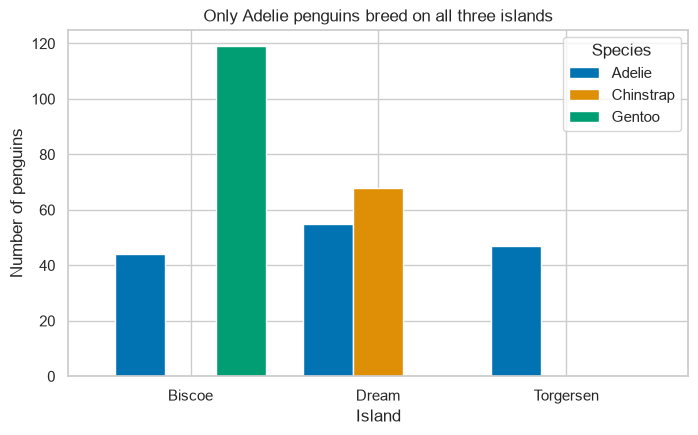

In [15]:
# Same crosstab, but islands as rows this time -- whatever is in the rows
# ends up on the x-axis of the bar chart.
counts = pd.crosstab(df["island"], df["species"])

fig, ax = plt.subplots(figsize=(8, 4.5))
counts.plot.bar(ax=ax,                  # draw onto our axes
                color=SPECIES_COLORS,   # our fixed species colors
                width=0.8,
                edgecolor="white")      # thin white outline separating the bars
ax.set_xlabel("Island")
ax.set_ylabel("Number of penguins")
ax.set_title("Only Adelie penguins breed on all three islands")
ax.legend(title="Species")
ax.tick_params(axis="x", rotation=0)    # keep the island names horizontal
plt.show()

## 7. New columns from old

Assign to a column name that doesn't exist yet, and pandas creates it — computed for every row at once (vectorized, like Module 01).

Bill length ÷ bill depth is a real **shape ratio**: long-thin-billed penguins (fish chasers) vs short-deep-billed ones (krill crushers).

In [16]:
# One division creates the whole column: each penguin's length / its own depth.
df["bill_ratio"] = df["bill_length_mm"] / df["bill_depth_mm"]

df[["species", "bill_length_mm", "bill_depth_mm", "bill_ratio"]].head()

,species,bill_length_mm,bill_depth_mm,bill_ratio
0,Adelie,39.1,18.7,2.090909
1,Adelie,39.5,17.4,2.270115
2,Adelie,40.3,18.0,2.238889
4,Adelie,36.7,19.3,1.901554
5,Adelie,39.3,20.6,1.907767


## 8. Group-by: split → apply → combine

In Module 01, per-species means took a loop with masks. `groupby` does it in one line:

1. **split** the table into one group per species
2. **apply** a function (like `mean`) to each group
3. **combine** the results into a new table

In [17]:
# Split by species, average three columns within each group, combine the results.
df.groupby("species")[["body_mass_g", "flipper_length_mm", "bill_ratio"]].mean().round(2)

,body_mass_g,flipper_length_mm,bill_ratio
species,,,
Adelie,3706.16,190.10,2.12
Chinstrap,3733.09,195.82,2.65
Gentoo,5092.44,217.24,3.18


In [18]:
# Group by TWO columns -> one result row per species/sex combination.
# .agg([...]) asks for several summaries at once ('agg' = aggregate).
df.groupby(["species", "sex"])["body_mass_g"].agg(["mean", "count"]).round(0)

mean  count
species   sex                  
Adelie    female  3369.0     73
          male    4043.0     73
Chinstrap female  3527.0     34
          male    3939.0     34
Gentoo    female  4680.0     58
          male    5485.0     61

Gentoos are ~1 kg heavier than the others, and in every species males outweigh females — sexual dimorphism, quantified in two lines.

## 9. Sorting

In [19]:
# ascending=False = biggest first. sort_values returns a NEW sorted table;
# df itself stays in its original order.
heaviest = df.sort_values("body_mass_g", ascending=False)
heaviest[["species", "island", "sex", "body_mass_g"]].head(5)

,species,island,sex,body_mass_g
169,Gentoo,Biscoe,male,6300.0
185,Gentoo,Biscoe,male,6050.0
269,Gentoo,Biscoe,male,6000.0
229,Gentoo,Biscoe,male,6000.0
263,Gentoo,Biscoe,male,5950.0


## 10. Distributions by group: the box plot

A box plot shows a distribution as a box (the middle 50% of values, with a line at the median) and whiskers (the tails) — ideal for comparing a measurement across groups.

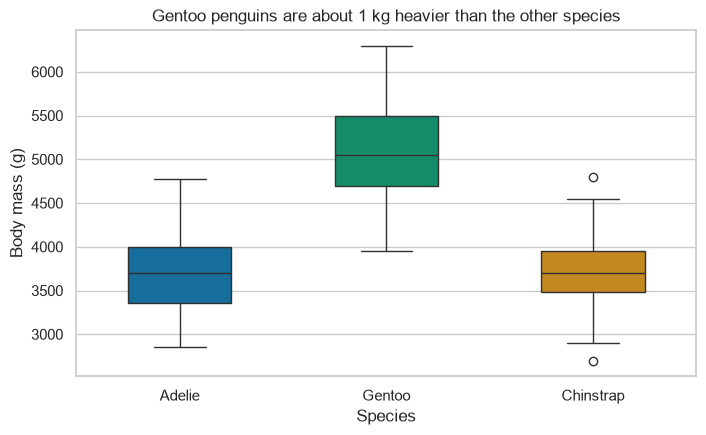

In [20]:
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.boxplot(data=df,
            x="species",              # one box per species
            y="body_mass_g",          # the measurement being compared
            hue="species",            # color the boxes by species...
            palette=SPECIES_COLORS,   # ...using our fixed colors
            width=0.5,                # slimmer boxes
            ax=ax)                    # draw onto our axes
ax.set_xlabel("Species")
ax.set_ylabel("Body mass (g)")
ax.set_title("Gentoo penguins are about 1 kg heavier than the other species")
plt.show()

## 11. The classic penguin plot

Flipper length vs body mass, colored by species. Bigger birds have bigger flippers *within* each species — and the species form distinct clusters, just like the iris clouds in Module 01.

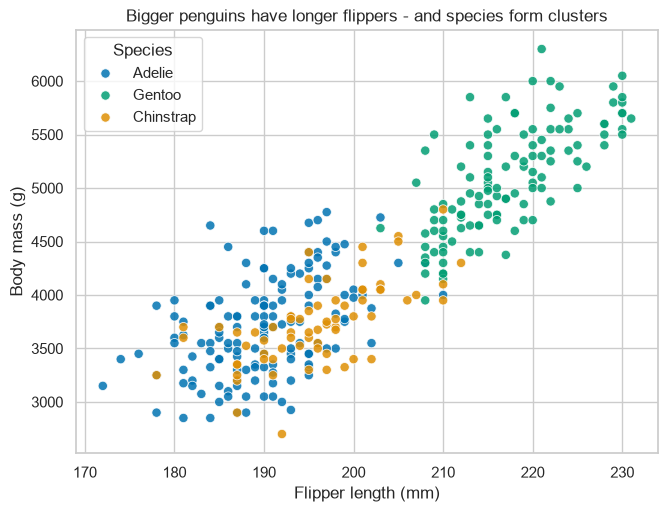

In [21]:
fig, ax = plt.subplots(figsize=(7.5, 5.5))

# seaborn's scatterplot handles the per-species coloring for us:
# hue='species' means 'one color per species value'.
sns.scatterplot(data=df,
                x="flipper_length_mm",
                y="body_mass_g",
                hue="species",
                palette=SPECIES_COLORS,
                s=45,                    # dot size
                alpha=0.85,              # slight transparency
                edgecolor="white",       # white rim around dots
                linewidth=0.6,
                ax=ax)
ax.set_xlabel("Flipper length (mm)")
ax.set_ylabel("Body mass (g)")
ax.set_title("Bigger penguins have longer flippers - and species form clusters")
ax.legend(title="Species")
plt.show()

## Recap

| Idea | Code |
|---|---|
| First look | `df.head()`, `df.shape`, `df.info()`, `df.describe()` |
| Missing data | `df.isna().sum()`, `df.dropna()` |
| One / several columns | `df["mass"]`, `df[["species", "mass"]]` |
| Filter | `df[(df["species"] == "Gentoo") & (df["sex"] == "female")]` |
| Count categories | `df["species"].value_counts()`, `pd.crosstab(...)` |
| New column | `df["ratio"] = df["a"] / df["b"]` |
| Split → apply → combine | `df.groupby("species")["mass"].mean()` |
| Sort | `df.sort_values("mass", ascending=False)` |

Next: [exercises.md](exercises.md). The missing-data question (#5) is the most important one — it's about scientific judgment, not syntax.